# Tugas Pre-processing Ulasan Aplikasi KAI

Notebook ini dibuat untuk mengerjakan `tugas_pertemuan_kedua` *Text Mining* menggunakan dataset `raw_playstore_reviews.csv`.

Tujuan utama:
1. Mengidentifikasi dan mengkategorikan noise pada setiap ulasan.
2. Membangun pipeline pre-processing minimal (noise removal, case folding, tokenization, stop words removal).
3. Menampilkan tabel sebelum vs sesudah pada ulasan dengan noise tertinggi.
4. Mengambil 10 kata paling sering muncul dari output akhir pipeline.
5. Membandingkan Pipeline A dan Pipeline B menggunakan metrik kuantitatif.

## 1) Setup

Berikut step by step nya:
- Proses dibuat reproducible (konstanta path dan random seed).
- Ada validasi kolom penting sebelum pemrosesan.
- Fungsi dibuat modular agar mudah diuji ulang.
- Setiap tahap preprocessing disimpan agar jejak proses transparan.
- Pipeline A (baseline) dan Pipeline B (enhanced) dipisah agar perbandingan adil.

In [21]:
import re
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import subprocess
import sys

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", None)

DATA_PATH = Path("raw_playstore_reviews.csv")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2) Load Data dan Validasi Awal

Tahap ini memastikan data siap diproses:
- membaca CSV,
- memeriksa kolom wajib (`reviewId`, `content`, `score`, `at`),
- menangani nilai kosong pada kolom `content`.

In [22]:
df = pd.read_csv(DATA_PATH)

required_columns = {"reviewId", "content", "score", "at"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Kolom wajib tidak ditemukan: {sorted(missing_columns)}")

df["content"] = df["content"].fillna("").astype(str)

print(f"Jumlah baris: {len(df):,}")
print(f"Jumlah kolom: {len(df.columns)}")
display(df.head(5))

Jumlah baris: 1,000
Jumlah kolom: 6


,reviewId,userName,score,at,content,thumbsUpCount
0,ce885e23-4671-4f83-8255-7c56d948c97c,SATRIA,1,2026-03-13 18:42:08,"KALIAN SEGITU BANYAKNYA STAFF DAN PEGAWAI, NELFON KE CS DOANG GADA YG ANGKAT. SISTEM MAU BATALKAN TIKET SAJA DIPERAULIT..INI KENA BADAI SY..MAU AJUKAN RESCHEDULE.. MALAH CS NYA...",0
1,2a25722f-14a8-4c71-b434-a67a81037fb3,Matusin,1,2026-03-13 18:40:08,"APK YANG KETIKA PENGGUNANYA RAME ATAU SEDANG WAR DISURUH GANTI GANTIAN PESANNYA (CONECTING TRAIN), GANGGUAN TERUS TAPI GAADA PERUBAHAN DAN PERBAIKAN",0
2,dbd57e26-40f9-49ae-84ef-12a1dcad9fee,Edi Poerwantoe,5,2026-03-13 18:28:33,good,0
3,71d7889a-2e69-43ed-8dd1-d3d01a396c07,Wara Hapsari,1,2026-03-13 17:26:03,"aplikasi terjelek sejagad raya, pemilihan pembayaran tidak bisa dilakukan.Tabah lama tambah jelek aja, dulu nggak masalah sekarang ampun dah. Dan pembayaran terlalu cepat kadal...",0
4,093f1779-1300-4340-8077-76725501391d,Wahyu Triwibowo,5,2026-03-13 16:52:18,mantab,0


## 3) Identifikasi dan Kategorisasi Noise (Setiap Ulasan)

Kategori noise yang dideteksi (rule-based):
- `uppercase_text`: dominasi huruf kapital.
- `elongated_chars`: huruf berulang berlebihan (`baguuuus`, `erroooor`).
- `punctuation_flood`: tanda baca berulang (`!!!`, `???`, `...`).
- `numeric_noise`: mengandung angka.
- `emoji_or_non_ascii_symbol`: emoji/simbol non-ASCII.
- `slang_or_nonstandard`: kata tidak baku/slang (`gk`, `ga`, `apk`, dll).
- `profanity`: kata kasar.
- `english_mixed`: ada kata Inggris teknis/umum.
- `very_short_review`: ulasan sangat pendek (<= 2 token).

Satu ulasan bisa memiliki lebih dari satu kategori noise.

In [23]:
SLANG_TERMS = {
    "gk", "ga", "gak", "ngga", "nggak", "tdk", "yg", "dr", "krn",
    "tp", "trs", "sdh", "udh", "klo", "kalo", "bgt", "bngt", "apk",
    "apknya", "nih", "aja", "kmrn", "min"
}

PROFANITY_TERMS = {"tolol", "kntl", "kuntul", "bangke", "sampah", "haram"}

ENGLISH_HINT_WORDS = {
    "good", "loading", "server", "error", "update", "friendly",
    "simple", "service", "app", "chat", "payment", "connect"
}

def uppercase_ratio(text: str) -> float:
    letters = re.findall(r"[A-Za-z]", text)
    if not letters:
        return 0.0
    return sum(ch.isupper() for ch in letters) / len(letters)

def detect_noise_categories(text: str) -> list:
    text = text or ""
    categories = []

    if uppercase_ratio(text) >= 0.70 and len(re.findall(r"[A-Za-z]", text)) >= 8:
        categories.append("uppercase_text")
    if re.search(r"(.)\1{2,}", text.lower()):
        categories.append("elongated_chars")
    if re.search(r"[!?.,]{2,}", text):
        categories.append("punctuation_flood")
    if re.search(r"\d", text):
        categories.append("numeric_noise")
    if re.search(r"[^\x00-\x7F]", text):
        categories.append("emoji_or_non_ascii_symbol")

    alpha_tokens = re.findall(r"[A-Za-z]+", text.lower())
    if any(tok in SLANG_TERMS for tok in alpha_tokens):
        categories.append("slang_or_nonstandard")
    if any(tok in PROFANITY_TERMS for tok in alpha_tokens):
        categories.append("profanity")
    if any(tok in ENGLISH_HINT_WORDS for tok in alpha_tokens):
        categories.append("english_mixed")
    if len(alpha_tokens) <= 2:
        categories.append("very_short_review")

    if not categories:
        categories = ["clean_or_low_noise"]

    return categories

In [24]:
noise_df = df.copy()
noise_df["noise_categories"] = noise_df["content"].apply(detect_noise_categories)
noise_df["noise_count"] = noise_df["noise_categories"].apply(
    lambda cats: 0 if cats == ["clean_or_low_noise"] else len(cats)
)

noise_distribution = (
    noise_df.explode("noise_categories")["noise_categories"]
    .value_counts()
    .rename_axis("noise_category")
    .reset_index(name="review_count")
)

print("Contoh identifikasi noise per ulasan (10 baris pertama):")
display(noise_df[["reviewId", "content", "noise_categories", "noise_count"]].head(10))

print("Distribusi kategori noise:")
display(noise_distribution)

print("Validasi: semua ulasan memiliki label noise ->", noise_df["noise_categories"].isna().sum() == 0)

Contoh identifikasi noise per ulasan (10 baris pertama):


,reviewId,content,noise_categories,noise_count
0,ce885e23-4671-4f83-8255-7c56d948c97c,"KALIAN SEGITU BANYAKNYA STAFF DAN PEGAWAI, NELFON KE CS DOANG GADA YG ANGKAT. SISTEM MAU BATALKAN TIKET SAJA DIPERAULIT..INI KENA BADAI SY..MAU AJUKAN RESCHEDULE.. MALAH CS NYA...","[uppercase_text, elongated_chars, punctuation_flood, slang_or_nonstandard, english_mixed]",5
1,2a25722f-14a8-4c71-b434-a67a81037fb3,"APK YANG KETIKA PENGGUNANYA RAME ATAU SEDANG WAR DISURUH GANTI GANTIAN PESANNYA (CONECTING TRAIN), GANGGUAN TERUS TAPI GAADA PERUBAHAN DAN PERBAIKAN","[uppercase_text, slang_or_nonstandard]",2
2,dbd57e26-40f9-49ae-84ef-12a1dcad9fee,good,"[english_mixed, very_short_review]",2
3,71d7889a-2e69-43ed-8dd1-d3d01a396c07,"aplikasi terjelek sejagad raya, pemilihan pembayaran tidak bisa dilakukan.Tabah lama tambah jelek aja, dulu nggak masalah sekarang ampun dah. Dan pembayaran terlalu cepat kadal...","[elongated_chars, punctuation_flood, slang_or_nonstandard]",3
4,093f1779-1300-4340-8077-76725501391d,mantab,[very_short_review],1
5,5744ecd8-73a6-4e62-b097-6ce69143a76d,tidak upgrade and daftar,[clean_or_low_noise],0
6,69c2105c-6a15-44da-b4bc-293bcade74fb,mudah,[very_short_review],1
7,b34dfc76-d7da-449a-8840-bcfc516b4d83,"Hp aman, jaringan bagus, tapi Loadingnya kaya maen RDR 2 di ps 3... lama banget parah. menghambat banget ni apk","[elongated_chars, punctuation_flood, numeric_noise, slang_or_nonstandard]",4
8,6c2fbadb-9de2-4568-bf00-ab1d01bb0583,terimksih kai skrg lebih mudah,[clean_or_low_noise],0
9,b834e14f-157e-4003-99ec-80453806cd18,Bagus sih mempermudah...cuma kurang dibagian pembayaran terbatas seharusnya diperluas lagi bisa lewat indomaret dll sehingga baik yg tidak mempunyai ATM bisa bayar . 2026 aplik...,"[elongated_chars, punctuation_flood, numeric_noise, slang_or_nonstandard, english_mixed]",5


Distribusi kategori noise:


,noise_category,review_count
0,very_short_review,379
1,slang_or_nonstandard,251
2,clean_or_low_noise,245
3,english_mixed,123
4,numeric_noise,112
5,punctuation_flood,110
6,elongated_chars,99
7,emoji_or_non_ascii_symbol,58
8,uppercase_text,14
9,profanity,9


Validasi: semua ulasan memiliki label noise -> True


## 4) Membuat Dua Pipeline Pre-processing

### Pipeline A (Baseline)
1. Noise removal
2. Case folding
3. Tokenization
4. Stop words removal

### Pipeline B (Enhanced)
Pipeline B menjalankan langkah Pipeline A +
- normalisasi huruf berulang (`erroooor` -> `error`),
- normalisasi slang/typo umum (`gk` -> `tidak`, `apk` -> `aplikasi`),
- penyaringan token sangat pendek (`len < 3`) untuk menekan noise residual.

Tujuan Pipeline B adalah menurunkan sparsity vocab dan meningkatkan konsistensi token.

In [25]:
STOPWORDS_ID = {
    "yang", "dan", "di", "ke", "dari", "untuk", "dengan", "ini", "itu",
    "atau", "karena", "pada", "ada", "saya", "aku", "kamu", "kami", "kita",
    "mereka", "dia", "nya", "ya", "aja", "juga", "udah", "sudah", "belum",
    "jadi", "agar", "biar", "lebih", "dalam", "saat", "lagi", "masih", "sih",
    "nih", "dong", "deh", "kok", "lah", "pun", "the", "a", "an", "to", "of"
}

SLANG_NORMALIZATION = {
    "gk": "tidak", "ga": "tidak", "gak": "tidak", "ngga": "tidak", "nggak": "tidak",
    "tdk": "tidak", "tp": "tapi", "yg": "yang", "dr": "dari", "krn": "karena",
    "trs": "terus", "sdh": "sudah", "udh": "sudah", "klo": "kalau", "kalo": "kalau",
    "bgt": "banget", "bngt": "banget", "apk": "aplikasi", "apknya": "aplikasi",
    "app": "aplikasi", "min": "admin", "cs": "customer_service", "kmrn": "kemarin"
}

TYPO_NORMALIZATION = {
    "eror": "error", "erro": "error", "lemot": "lambat", "ticket": "tiket",
    "mantapp": "mantap", "baguss": "bagus"
}

def remove_noise(text: str) -> str:
    text = text or ""
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@[A-Za-z0-9_]+|#[A-Za-z0-9_]+", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"[^A-Za-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def case_folding(text: str) -> str:
    return (text or "").lower().strip()

def tokenize(text: str) -> list:
    return re.findall(r"[a-z]+", text)

def remove_stopwords(tokens: list) -> list:
    return [tok for tok in tokens if tok not in STOPWORDS_ID and len(tok) > 1]

def normalize_repeated_chars(token: str) -> str:
    return re.sub(r"(.)\1{2,}", r"\1", token)

def normalize_tokens(tokens: list) -> list:
    normalized = []
    for tok in tokens:
        tok = normalize_repeated_chars(tok)
        tok = SLANG_NORMALIZATION.get(tok, tok)
        tok = TYPO_NORMALIZATION.get(tok, tok)
        normalized.append(tok)
    return normalized

def pipeline_a(text: str) -> dict:
    stage_noise_removed = remove_noise(text)
    stage_case_folded = case_folding(stage_noise_removed)
    stage_tokens = tokenize(stage_case_folded)
    stage_final = remove_stopwords(stage_tokens)
    return {
        "noise_removed": stage_noise_removed,
        "case_folded": stage_case_folded,
        "tokens": stage_tokens,
        "final_tokens": stage_final,
    }

def pipeline_b(text: str) -> dict:
    stage_noise_removed = remove_noise(text)
    stage_case_folded = case_folding(stage_noise_removed)
    stage_tokens = tokenize(stage_case_folded)
    stage_normalized = normalize_tokens(stage_tokens)
    stage_stopword_removed = remove_stopwords(stage_normalized)
    stage_final = [tok for tok in stage_stopword_removed if len(tok) >= 3]
    return {
        "noise_removed": stage_noise_removed,
        "case_folded": stage_case_folded,
        "tokens": stage_tokens,
        "normalized_tokens": stage_normalized,
        "final_tokens": stage_final,
    }

In [26]:
a_stages = noise_df["content"].apply(pipeline_a).apply(pd.Series).add_prefix("a_")
b_stages = noise_df["content"].apply(pipeline_b).apply(pd.Series).add_prefix("b_")
processed_df = pd.concat([noise_df, a_stages, b_stages], axis=1)

print("Contoh hasil akhir preprocessing (Pipeline A vs B):")
display(processed_df[["reviewId", "content", "noise_categories", "a_final_tokens", "b_final_tokens"]].head(10))

Contoh hasil akhir preprocessing (Pipeline A vs B):


,reviewId,content,noise_categories,a_final_tokens,b_final_tokens
0,ce885e23-4671-4f83-8255-7c56d948c97c,"KALIAN SEGITU BANYAKNYA STAFF DAN PEGAWAI, NELFON KE CS DOANG GADA YG ANGKAT. SISTEM MAU BATALKAN TIKET SAJA DIPERAULIT..INI KENA BADAI SY..MAU AJUKAN RESCHEDULE.. MALAH CS NYA...","[uppercase_text, elongated_chars, punctuation_flood, slang_or_nonstandard, english_mixed]","[kalian, segitu, banyaknya, staff, pegawai, nelfon, cs, doang, gada, yg, angkat, sistem, mau, batalkan, tiket, saja, diperaulit, kena, badai, sy, mau, ajukan, reschedule, malah...","[kalian, segitu, banyaknya, staff, pegawai, nelfon, customer_service, doang, gada, angkat, sistem, mau, batalkan, tiket, saja, diperaulit, kena, badai, mau, ajukan, reschedule,..."
1,2a25722f-14a8-4c71-b434-a67a81037fb3,"APK YANG KETIKA PENGGUNANYA RAME ATAU SEDANG WAR DISURUH GANTI GANTIAN PESANNYA (CONECTING TRAIN), GANGGUAN TERUS TAPI GAADA PERUBAHAN DAN PERBAIKAN","[uppercase_text, slang_or_nonstandard]","[apk, ketika, penggunanya, rame, sedang, war, disuruh, ganti, gantian, pesannya, conecting, train, gangguan, terus, tapi, gaada, perubahan, perbaikan]","[aplikasi, ketika, penggunanya, rame, sedang, war, disuruh, ganti, gantian, pesannya, conecting, train, gangguan, terus, tapi, gaada, perubahan, perbaikan]"
2,dbd57e26-40f9-49ae-84ef-12a1dcad9fee,good,"[english_mixed, very_short_review]",[good],[good]
3,71d7889a-2e69-43ed-8dd1-d3d01a396c07,"aplikasi terjelek sejagad raya, pemilihan pembayaran tidak bisa dilakukan.Tabah lama tambah jelek aja, dulu nggak masalah sekarang ampun dah. Dan pembayaran terlalu cepat kadal...","[elongated_chars, punctuation_flood, slang_or_nonstandard]","[aplikasi, terjelek, sejagad, raya, pemilihan, pembayaran, tidak, bisa, dilakukan, tabah, lama, tambah, jelek, dulu, nggak, masalah, sekarang, ampun, dah, pembayaran, terlalu, ...","[aplikasi, terjelek, sejagad, raya, pemilihan, pembayaran, tidak, bisa, dilakukan, tabah, lama, tambah, jelek, dulu, tidak, masalah, sekarang, ampun, dah, pembayaran, terlalu, ..."
4,093f1779-1300-4340-8077-76725501391d,mantab,[very_short_review],[mantab],[mantab]
5,5744ecd8-73a6-4e62-b097-6ce69143a76d,tidak upgrade and daftar,[clean_or_low_noise],"[tidak, upgrade, and, daftar]","[tidak, upgrade, and, daftar]"
6,69c2105c-6a15-44da-b4bc-293bcade74fb,mudah,[very_short_review],[mudah],[mudah]
7,b34dfc76-d7da-449a-8840-bcfc516b4d83,"Hp aman, jaringan bagus, tapi Loadingnya kaya maen RDR 2 di ps 3... lama banget parah. menghambat banget ni apk","[elongated_chars, punctuation_flood, numeric_noise, slang_or_nonstandard]","[hp, aman, jaringan, bagus, tapi, loadingnya, kaya, maen, rdr, ps, lama, banget, parah, menghambat, banget, ni, apk]","[aman, jaringan, bagus, tapi, loadingnya, kaya, maen, rdr, lama, banget, parah, menghambat, banget, aplikasi]"
8,6c2fbadb-9de2-4568-bf00-ab1d01bb0583,terimksih kai skrg lebih mudah,[clean_or_low_noise],"[terimksih, kai, skrg, mudah]","[terimksih, kai, skrg, mudah]"
9,b834e14f-157e-4003-99ec-80453806cd18,Bagus sih mempermudah...cuma kurang dibagian pembayaran terbatas seharusnya diperluas lagi bisa lewat indomaret dll sehingga baik yg tidak mempunyai ATM bisa bayar . 2026 aplik...,"[elongated_chars, punctuation_flood, numeric_noise, slang_or_nonstandard, english_mixed]","[bagus, mempermudah, cuma, kurang, dibagian, pembayaran, terbatas, seharusnya, diperluas, bisa, lewat, indomaret, dll, sehingga, baik, yg, tidak, mempunyai, atm, bisa, bayar, a...","[bagus, mempermudah, cuma, kurang, dibagian, pembayaran, terbatas, seharusnya, diperluas, bisa, lewat, indomaret, dll, sehingga, baik, tidak, mempunyai, atm, bisa, bayar, aplik..."


## 5) Tabel Sebelum vs Sesudah (Ulasan Dengan Noise Tertinggi)

Strategi:
- Ulasan diurutkan berdasarkan `noise_count` tertinggi.
- Diambil 5 ulasan teratas agar perubahan tiap tahap terlihat jelas.

Kolom yang ditampilkan:
- teks asli,
- hasil noise removal,
- hasil case folding,
- hasil tokenization,
- hasil stop words removal (Pipeline A),
- hasil akhir Pipeline B.

In [27]:
noisiest_reviews = processed_df.sort_values("noise_count", ascending=False).head(5).copy()

comparison_cols = [
    "reviewId",
    "noise_categories",
    "content",
    "a_noise_removed",
    "a_case_folded",
    "a_tokens",
    "a_final_tokens",
    "b_final_tokens",
]

before_after_table = noisiest_reviews[comparison_cols].copy()

list_columns = ["noise_categories", "a_tokens", "a_final_tokens", "b_final_tokens"]
for col in list_columns:
    before_after_table[col] = before_after_table[col].apply(
        lambda x: ' | '.join(x) if isinstance(x, list) else x
    )

display(before_after_table)

,reviewId,noise_categories,content,a_noise_removed,a_case_folded,a_tokens,a_final_tokens,b_final_tokens
0,ce885e23-4671-4f83-8255-7c56d948c97c,uppercase_text | elongated_chars | punctuation_flood | slang_or_nonstandard | english_mixed,"KALIAN SEGITU BANYAKNYA STAFF DAN PEGAWAI, NELFON KE CS DOANG GADA YG ANGKAT. SISTEM MAU BATALKAN TIKET SAJA DIPERAULIT..INI KENA BADAI SY..MAU AJUKAN RESCHEDULE.. MALAH CS NYA...",KALIAN SEGITU BANYAKNYA STAFF DAN PEGAWAI NELFON KE CS DOANG GADA YG ANGKAT SISTEM MAU BATALKAN TIKET SAJA DIPERAULIT INI KENA BADAI SY MAU AJUKAN RESCHEDULE MALAH CS NYA NGILA...,kalian segitu banyaknya staff dan pegawai nelfon ke cs doang gada yg angkat sistem mau batalkan tiket saja diperaulit ini kena badai sy mau ajukan reschedule malah cs nya ngila...,kalian | segitu | banyaknya | staff | dan | pegawai | nelfon | ke | cs | doang | gada | yg | angkat | sistem | mau | batalkan | tiket | saja | diperaulit | ini | kena | badai |...,kalian | segitu | banyaknya | staff | pegawai | nelfon | cs | doang | gada | yg | angkat | sistem | mau | batalkan | tiket | saja | diperaulit | kena | badai | sy | mau | ajuka...,kalian | segitu | banyaknya | staff | pegawai | nelfon | customer_service | doang | gada | angkat | sistem | mau | batalkan | tiket | saja | diperaulit | kena | badai | mau | a...
959,691b3726-fe2a-4b0f-9640-9767de102b56,elongated_chars | punctuation_flood | emoji_or_non_ascii_symbol | slang_or_nonstandard | english_mixed,sumpah ini aplikasi sangat menguras emosi.....dibelain melek sampai dini hari demi boking tiket dengan kursi pilihan aja susahnya error melulu ....giliran kena eh kursi malah s...,sumpah ini aplikasi sangat menguras emosi dibelain melek sampai dini hari demi boking tiket dengan kursi pilihan aja susahnya error melulu giliran kena eh kursi malah sudah pad...,sumpah ini aplikasi sangat menguras emosi dibelain melek sampai dini hari demi boking tiket dengan kursi pilihan aja susahnya error melulu giliran kena eh kursi malah sudah pad...,sumpah | ini | aplikasi | sangat | menguras | emosi | dibelain | melek | sampai | dini | hari | demi | boking | tiket | dengan | kursi | pilihan | aja | susahnya | error | melu...,sumpah | aplikasi | sangat | menguras | emosi | dibelain | melek | sampai | dini | hari | demi | boking | tiket | kursi | pilihan | susahnya | error | melulu | giliran | kena |...,sumpah | aplikasi | sangat | menguras | emosi | dibelain | melek | sampai | dini | hari | demi | boking | tiket | kursi | pilihan | susahnya | error | melulu | giliran | kena |...
155,924e0cb6-78da-4e00-8cd3-e5d3daf597d1,uppercase_text | elongated_chars | punctuation_flood | slang_or_nonstandard | profanity,APLIKASI BIKIN BEBAN !!!! MAU CANCEL AJA HARUS KIRIM OTP EMAIL DAN NO HP.. PARAH MAKAN UANG HARAM HAK PENUMPANG KAI.!!!,APLIKASI BIKIN BEBAN MAU CANCEL AJA HARUS KIRIM OTP EMAIL DAN NO HP PARAH MAKAN UANG HARAM HAK PENUMPANG KAI,aplikasi bikin beban mau cancel aja harus kirim otp email dan no hp parah makan uang haram hak penumpang kai,aplikasi | bikin | beban | mau | cancel | aja | harus | kirim | otp | email | dan | no | hp | parah | makan | uang | haram | hak | penumpang | kai,aplikasi | bikin | beban | mau | cancel | harus | kirim | otp | email | no | hp | parah | makan | uang | haram | hak | penumpang | kai,aplikasi | bikin | beban | mau | cancel | harus | kirim | otp | email | parah | makan | uang | haram | hak | penumpang | kai
9,b834e14f-157e-4003-99ec-80453806cd18,elongated_chars | punctuation_flood | numeric_noise | slang_or_nonstandard | english_mixed,Bagus sih mempermudah...cuma kurang dibagian pembayaran terbatas seharusnya diperluas lagi bisa lewat indomaret dll sehingga baik yg tidak mempunyai ATM bisa bayar . 2026 aplik...,Bagus sih mempermudah cuma kurang dibagian pembayaran terbatas seharusnya diperluas lagi bisa lewat indomaret dll sehingga baik yg tidak mempunyai ATM bisa bayar aplikasinya sk...,bagus sih mempermudah cuma kurang dibagian pembayaran terbatas seharusnya diperluas lagi bisa l

## 6) Top 10 Kata Paling Sering Muncul dan Word Cloud

Frekuensi kata dihitung dari output akhir pipeline menggunakan `Counter`.

Pada notebook ini, top words diambil dari **Pipeline B** karena token sudah dinormalisasi lebih baik sehingga lebih representatif untuk tema dataset.

Selain tabel top 10, visualisasi dilakukan menggunakan **word cloud** agar kata dominan lebih mudah terlihat secara visual.

,kata,frekuensi
0,tidak,331
1,tiket,215
2,aplikasi,214
3,bisa,190
4,sangat,118
5,bagus,113
6,kai,102
7,mau,94
8,kereta,76
9,tapi,68


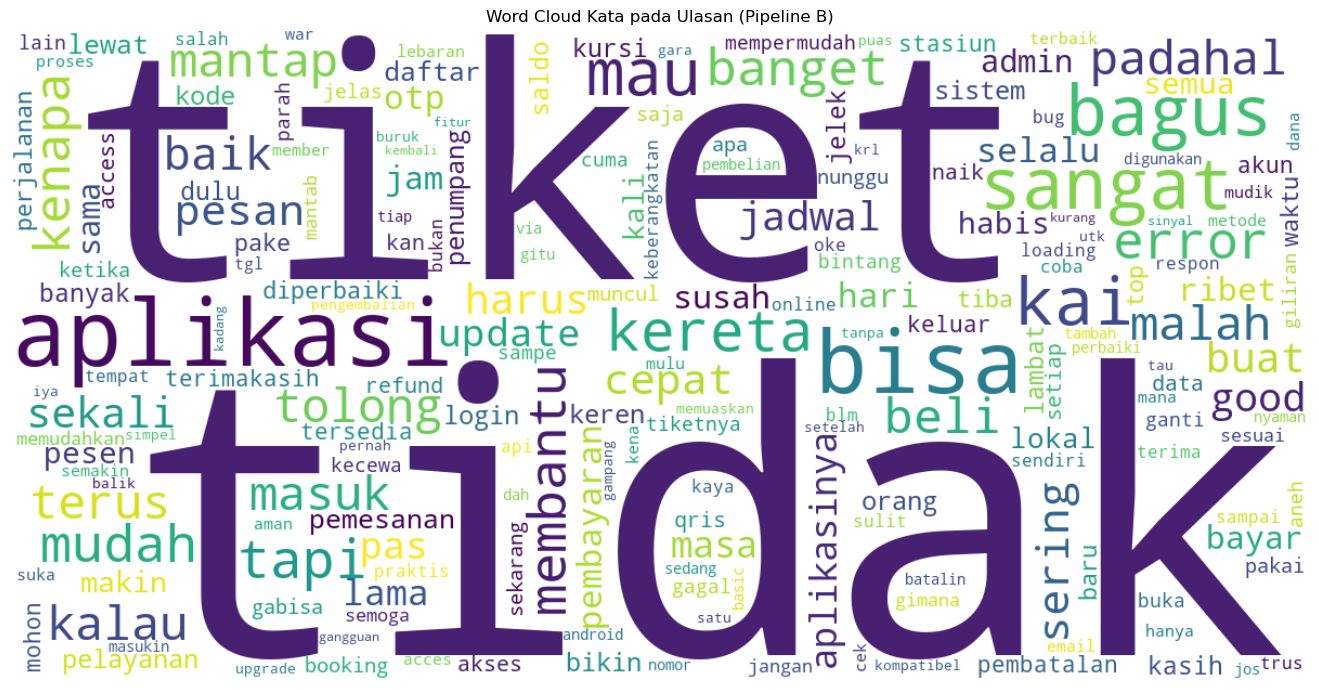

In [ ]:
all_tokens_b = [tok for tokens in processed_df["b_final_tokens"] for tok in tokens]
token_freq = Counter(all_tokens_b)
# Tampilkan 10 kata paling umum beserta frekuensinya
top_10_words = token_freq.most_common(10)
top_10_df = pd.DataFrame(top_10_words, columns=["kata", "frekuensi"])
display(top_10_df)

try:
    WordCloud = importlib.import_module("wordcloud").WordCloud
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud"])
    WordCloud = importlib.import_module("wordcloud").WordCloud

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",
    max_words=200,
    random_state=RANDOM_SEED,
).generate_from_frequencies(token_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Kata pada Ulasan (Pipeline B)")
plt.tight_layout()
plt.show()

### Interpretasi Top Words
Jika kata yang muncul didominasi istilah seperti `aplikasi`, `tiket`, `error`, `bayar`, `jadwal`, `loading`, maka kata-kata tersebut merepresentasikan isi dataset dengan baik.

Alasannya: mayoritas ulasan memang membahas kendala performa aplikasi, pemesanan tiket, dan proses pembayaran/refund.

## 7) Perbandingan Pipeline A vs Pipeline B

Metrik yang dihitung untuk masing-masing pipeline:
1. `total_token`: total semua token pasca pre-processing.
2. `vocab_unik`: jumlah token unik.
3. `rata_rata_panjang_dokumen`: rata-rata jumlah token per ulasan.

In [29]:
def calculate_metrics(token_series: pd.Series) -> dict:
    lengths = token_series.apply(len)
    total_token = int(lengths.sum())
    vocab_unik = len({tok for tokens in token_series for tok in tokens})
    rata_rata_panjang_dokumen = float(lengths.mean())
    return {
        "total_token": total_token,
        "vocab_unik": vocab_unik,
        "rata_rata_panjang_dokumen": round(rata_rata_panjang_dokumen, 2),
    }

metrics_a = calculate_metrics(processed_df["a_final_tokens"])
metrics_b = calculate_metrics(processed_df["b_final_tokens"])

comparison_metrics = pd.DataFrame([
    {"pipeline": "Pipeline A", **metrics_a},
    {"pipeline": "Pipeline B", **metrics_b},
])
display(comparison_metrics)

,pipeline,total_token,vocab_unik,rata_rata_panjang_dokumen
0,Pipeline A,8178,1977,8.18
1,Pipeline B,7858,1861,7.86


## 8) Analisis Pipeline Mana yang Lebih Baik

Cara membaca hasil:
- `vocab_unik` lebih kecil (secara wajar) menandakan normalisasi berhasil menyatukan variasi kata noisy.
- `total_token` yang turun moderat menandakan noise berkurang tanpa kehilangan terlalu banyak informasi.
- Jika rata-rata panjang dokumen turun terlalu ekstrem, ada risiko over-cleaning.

Dalam praktik text mining ulasan aplikasi, **Pipeline B** biasanya lebih baik karena mengurangi variasi slang/typo sehingga representasi teks lebih konsisten.

Kesimpulan final mengikuti angka pada tabel metrik yang dihasilkan di cell sebelumnya.